In [67]:
import os # import the 'os' module which allows me interaction with the operating system
os.environ["OMP_NUM_THREADS"] = "1" 
# Sets the environmnet variable to limit the number of threads used by OpenMP which helps to prevent performance issues or crashes when running in limited resource environmnets

In [68]:
import numpy as np # library for numerical computing

import matplotlib.pyplot as plt # library for data visualization

import pandas as pd #library for data manipulation and analysis

import seaborn as sns # library for data visualizatiion

from sklearn.preprocessing import StandardScaler # StandardScaler , which standardizes features 

from sklearn.model_selection import train_test_split #function to split dataset into training and testing sets

from sklearn.linear_model import LinearRegression # Linear regression model from scikit for predicting

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # performance metrics to evaluate regression model

from sklearn.cluster import KMeans #clustering algorithm for unsupervised learning

from sklearn.metrics import silhouette_score, davies_bouldin_score #evaluation metrics for clustering

from sklearn.cluster import AgglomerativeClustering # a type of hierarchical clustering algorithm

In [69]:
life_df = pd.read_csv('life_expectancy_data.csv') # reading in the CSV file using pandas

In [70]:
life_df.head() # checking the first five rows of the dataset

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,GDP,Life expectancy class
0,Afghanistan,2015,Developing,65.0,263.0,62,584.259210,Low
1,Albania,2015,Developing,77.8,74.0,0,3954.227830,High
2,Algeria,2015,Developing,75.6,19.0,21,4132.762920,Medium
3,Angola,2015,Developing,52.4,335.0,66,3695.793748,Low
4,Antigua and Barbuda,2015,Developing,76.4,13.0,0,13566.954100,High


In [71]:
life_df.info() #checking for null values and data type in our dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                183 non-null    object 
 1   Year                   183 non-null    int64  
 2   Status                 183 non-null    object 
 3   Life expectancy        183 non-null    float64
 4   Adult Mortality        183 non-null    float64
 5   infant deaths          183 non-null    int64  
 6   GDP                    183 non-null    float64
 7   Life expectancy class  183 non-null    object 
dtypes: float64(3), int64(2), object(3)
memory usage: 11.6+ KB


# Exercise 2a:
## Lets start by making a 1D histogram of the life expectancy of all countries in the dataset

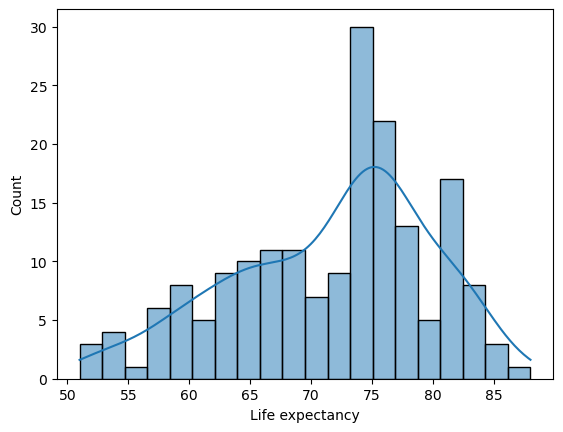

In [72]:
# create a histogram with a KDE  to visualize to distribution of life expectancy
sns.histplot(life_df['Life expectancy'], bins=20, kde=True)

#save the plot as a PNG file with name 'Distribution of Life'
plt.savefig('Distribution Of Life Expectancy')

THe histogram is right skewed
Typical values :Most countries have life expectancies between 65 and 80 years, with a noticable peak around 70 - 75 years.

Lower end: A few countries have life expectancies below 60, indicating poorer health conditions.

Higher end: Some countries reach up to 85 years, sugessting very high standards of healthcare.
This general shape aligns with expectations: while many countries progress in healthcare, a few of then still face challenges that lower life expectancy

# Exercise 2b:
## We now want to see how the life expectancy depends on the other variables (i.e. features) in the dataset. Create three scatter plots that show the following:
### 1.A plot of life expectancy (y-axis) versus GDP (x-axis).
### 2.A plot of life expectancy (y-axis) versus Adult Mortality (x-axis).
### 3.A plot of life expectancy (y-axis) versus infant deaths (x-axis).

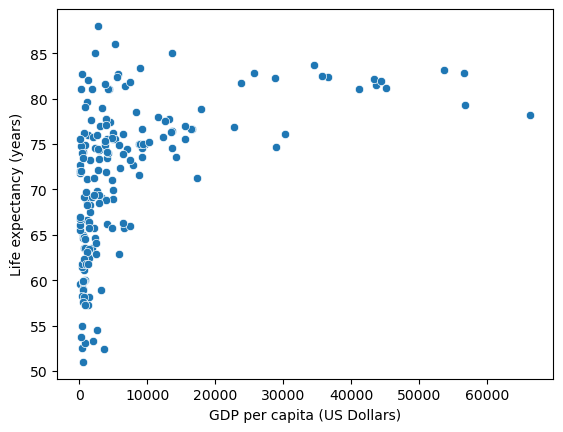

In [73]:
#create a scatter plot with GDP on the x-axis and Life expectancy on y-axis
sns.scatterplot(data=life_df, x="GDP", y='Life expectancy')

#Label both axes 
plt.xlabel('GDP per capita (US Dollars)')
plt.ylabel('Life expectancy (years)')
#save plot
plt.savefig('GDP vs Life expectancy')
#show figure
plt.show()

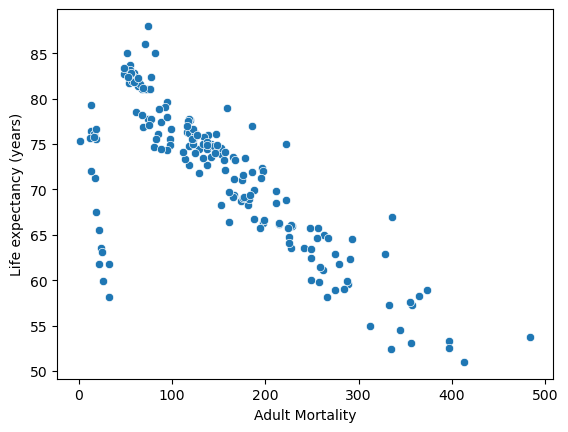

In [74]:
#create a scatter plot with Adult Mortality on the x-axis and Life expectancy on y-axis
sns.scatterplot(data=life_df, x="Adult Mortality", y='Life expectancy')

#Label both axes 
plt.xlabel('Adult Mortality')
plt.ylabel('Life expectancy (years)')

#save plot
plt.savefig('Adult Mortality vs Life Expectancy')
#show figure
plt.show()

### There seems to be a negative linear relationship between Adult Mortality with Life Expectancy

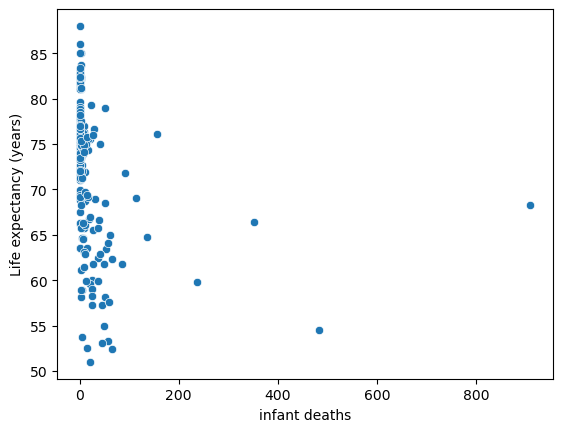

In [75]:
#create a scatter plot with Infantc on the x-axis and Life expectancy on y-axis
sns.scatterplot(data = life_df, x = "infant deaths",y = "Life expectancy")
# Label both axes 
plt.xlabel("infant deaths") 
plt.ylabel("Life expectancy (years)")

#save plot
plt.savefig('Life expectancy vs Infant Deaths')
# Show the figure
plt.show()

### Checking Correlation in the numerical columns

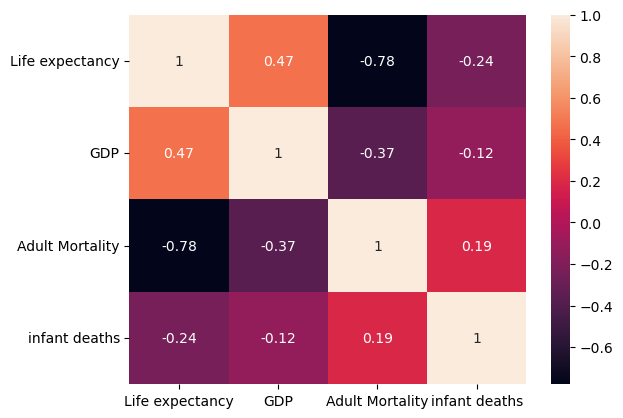

In [76]:
#define the list of columns from the dataframe to analyze
column_list = ["Life expectancy", "GDP", "Adult Mortality","infant deaths"]
#create a heatmap to visualise the correclation martix between the selected columns
sns.heatmap(life_df[column_list].corr(), annot=True)
#save the plot
plt.savefig('Correlation matrix')

## 1.Life Expectancy vs GDP:
### There is a positive correlation between GDP and Life expectancy.The relationship is not perfectly linear. But we notice that wealthier countries have higher Life expectancy: they taper off at a Higher GDP level. This is expected

## 2.Life Expectancy vs Adult Mortality:
### There is a strong negative correlation-higher adult mortality is associated with lower life expectancy. This makes intuitive sense since adult mortality directly impacts the average lifespan 

## 3.Life Expectancy vs Infant Deaths:
### There is a negative relationship-more infants deaths typically corresponds to lower life expectancy.Countries with high infact mortality usually struggle with healthcare which affects overall life expectancy

# Part I: Supervised learning models to predict life expectancy.

In [77]:
def Life_expectancy_predictor_with_plot(df, feature):
   # Extract the feature and target variable (Life expectancy) from the dataframe
    x = df[feature]
    y= df['Life expectancy']

    # reshape x to a 2D array for model fitting
    x= x.to_numpy().reshape(-1, 1)

    #split the data into training and testing set *80% train, 20% test)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

    #standardize the feature variables (scaling to mean 0 and variance of 1)
    scale = StandardScaler()
    scale.fit(x)
    x_train_scaled = scale.transform(x_train)
    x_test_scaled = scale.transform(x_test)

    # Initialize the linear regression model
    life_linear = LinearRegression()

    #fir the model to the scaled training data
    life_linear.fit(x_train_scaled, y_train)

    #predict life expectancy for the test data
    life_pred = life_linear.predict(x_test_scaled)

    # get the gradient (slope) and intercept of the linear regression 
    gradient = life_linear.coef_[0]
    intercept = life_linear.intercept_

    #Print the slope and intercept
    print('Gradient: ', gradient)
    print("Intercept: ",intercept)

    #calculate performance metrics for the model
    mean_abs = mean_absolute_error(y_test, life_pred)

    mean_squared = mean_squared_error(y_test, life_pred)

    rms_error = np.sqrt(mean_squared) #root mean squared serror

    R2 = r2_score(y_test, life_pred) ## R-squared

    # Print the results of these metrics.
    print("Mean absolute error: ", mean_abs) 
    print("Mean squared error: ", mean_squared)
    print("Root mean squared error: ", rms_error)
    print("R2: ", R2)

    # Generate data points for the fitted regression line
    x_fit = np.linspace(df[feature].min(), df[feature].max(), 200).reshape(-1, 1)
    
    x_fit_scaled = scale.transform(x_fit) # scale the new data points
    y_fit = life_linear.predict(x_fit_scaled) #Predict the y-values for the fitted line

    #create the scatter plot of the feature vs life expectancy
    sns.scatterplot(data=df, x=feature, y='Life expectancy')

    # plot the regression line on top of the scatter plot
    plt.plot(x_fit, y_fit)
    #label the axes and title the plot
    plt.xlabel(feature)
    plt.ylabel("Life Expectancy (years)")
    plt.title(f"Life Expectancy vs {feature}")
    #save the plot
    plt.savefig(f"Life Expectancy vs {feature} statistical trend")

    # display the plot
    plt.show()
    


# GDP vs Life Expectancy

Gradient:  3.736673077166571
Intercept:  71.8160790718866
Mean absolute error:  6.189693012844059
Mean squared error:  58.34352663502324
Root mean squared error:  7.638293437347326
R2:  0.15096662913593706


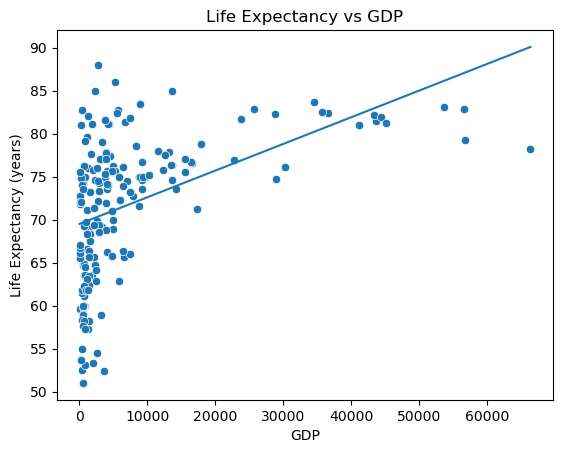

In [78]:
#call the function with 'life_df' DataFrame and 'GDP' features
Life_expectancy_predictor_with_plot(life_df, "GDP")

Gradient: 3.74

intercept 71.82

Mean Absolute Error (MAE): -  6.19 On Average,predictions are off by about 6 years

Mean Squared Error (MSE) = 58.34 
Root Mean Squared Error (RMSE): ≈ 7.64 years

R2 Score = 0.15 - Only about 15% 

This is not a particularly good model because the MAE and RMSE are relatively high for predicting life expectancy
The low R2 indicates that GDP alone is not a strong predictor-many other factors contribute to life expectancy

# Life Expectancy vs Adult Mortality:

Gradient:  -6.345929674459939
Intercept:  71.74857827731672
Mean absolute error:  3.613527279115094
Mean squared error:  27.828514734570348
Root mean squared error:  5.275273901378994
R2:  0.5950306909104605


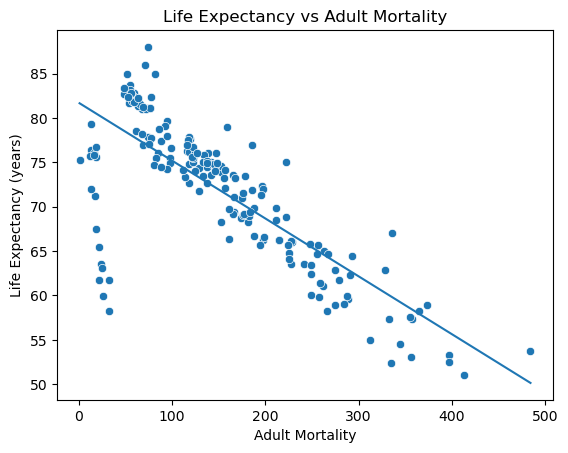

In [79]:
#call the function with 'life_df' DataFrame and 'Adult Mortality' features
Life_expectancy_predictor_with_plot(life_df, 'Adult Mortality')

Gradient:  -6.34

Intercept:  71.7
2
Mean absolute error:  3.
94
Mean squared error:  27
348
Root mean squared error:  
8994
R2: 04605

Adult Mortality directly measures deathrates in adults. if more adults die young, the average life expectancy must drop. Its a direct relationship

# Life Expectancy vs Infant Deaths

Gradient:  -1.7609479279049574
Intercept:  71.9912884597414
Mean absolute error:  6.800942529293993
Mean squared error:  67.93833618147521
Root mean squared error:  8.242471485026515
R2:  0.01133993939221789


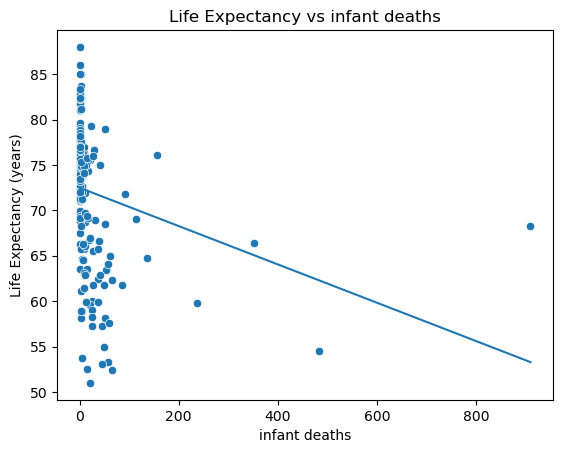

In [80]:
#call the function with 'life_df' DataFrame and 'Infant deaths' features
Life_expectancy_predictor_with_plot(life_df, 'infant deaths')

Gradient: -1.74

Intercept:  71.9912884597414

Mean absolute error:  6.800942529293993

Mean squared error:  67.93833618147521

Root mean squared error:  8.242471485026515

R2:  0.01133993939221789


This is not a particularly good model because the MAE and RMSE are relatively high for predicting life expectancy
The low R2 indicates that Infant Deaths alone is not a strong predictor-many other factors contribute to life expectancy.

IN CONCLUSION ADULT MORTALITY IS A BETTER PREDICTOR, ITS HAS A STRONGER, MORE DIRECT CORRELATION WITH LIFE EXPECTANCY. IT MAKE LOGICAL SENSE: DEATHRATE AFFECT LIFE SPAN MORE DIRECTLY THAN ECONOMIC OUTPUT OR DEATH OF INFANTS

# B. Explore the non-linearity of this relationship between life expectancy and GDP

In [81]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

def non_linearity(df, gdp, life_expectancy, degree):
    #Extract the feature (GDP) and target variable (Life expectancy) from the DataFrame
    x = df[gdp]
    
    y = df[life_expectancy]

    #Reshape the feature (GDP) to a 2D array for model fitting
    x = x.to_numpy().reshape(-1, 1)

    # split the data into training and testing set
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

    #standardize the feature variables (scaling to mean 0 and variance of 1)
    scale = StandardScaler()
    scale.fit(x)
    
    x_train_scaled = scale.transform(x_train)
    x_test_scaled = scale.transform(x_test)

    #intialize the polynomialFeatures transformer with given degree
    poly = PolynomialFeatures(degree = degree, include_bias=False)
    
    #transform the trainging data to include polynomial feature
    x_poly = poly.fit_transform(x_train_scaled)

    #Initialize the lInear Linear regression
    life_poly = LinearRegression()
    life_poly.fit(x_poly, y_train)

    # Get the co-effiecient and intercept of the polynomial regression model
    coeffiecients = life_poly.coef_
    intercept = life_poly.intercept_

   #transform the test data to include polynomial features
    x_test_poly = poly.fit_transform(x_test_scaled)
    
     # Predict life expectancy using the polynomial regression model
    life_pred = life_poly.predict(x_test_poly)

    #calculate and print the performance metrics 
    mean_abs = mean_absolute_error(y_test, life_pred)
    mean_squared = mean_squared_error(y_test, life_pred)
    
    rms_error = np.sqrt(mean_squared)
    R2 = r2_score(y_test, life_pred)
    print('Mean Abosolute error', mean_abs)
    print("Mean squared error", mean_squared)
    print("Root Mean squared error", rms_error)
    print('R2', R2)
    
    #return the trained model , scaler, polynomial transformer and r2 value for further use
    return life_poly, scale, poly, R2


Polynomial Degree: 2
Mean Abosolute error 5.512620340546638
Mean squared error 50.90032575507901
Root Mean squared error 7.134446422468881
R2 0.2592824320638293

Polynomial Degree: 3
Mean Abosolute error 5.460099497925596
Mean squared error 49.007583109405985
Root Mean squared error 7.0005416297173735
R2 0.28682621903246375

Polynomial Degree: 4
Mean Abosolute error 5.459779434241126
Mean squared error 47.96028795280578
Root Mean squared error 6.9253366671091
R2 0.30206678792471353

Polynomial Degree: 5
Mean Abosolute error 5.301940957867499
Mean squared error 46.49801277329318
Root Mean squared error 6.818945136404397
R2 0.3233462767797316


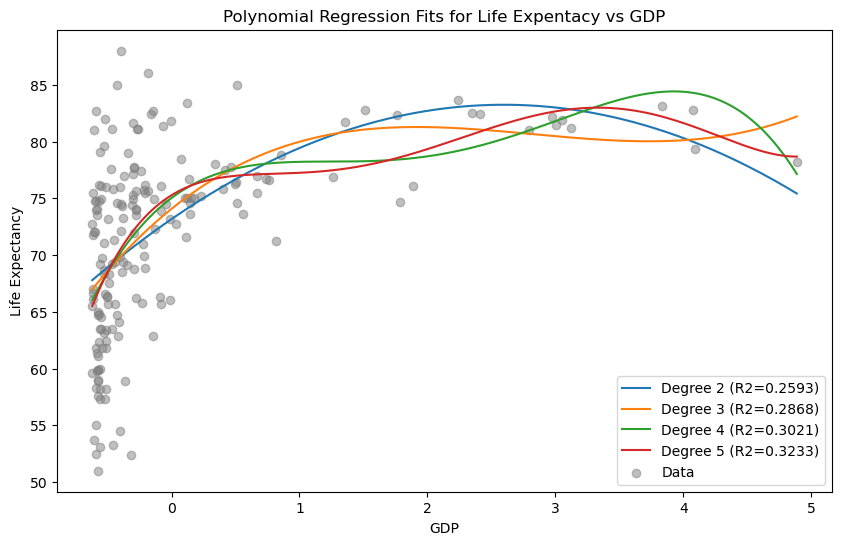

In [82]:
# Extract the features (GDP) and target variable (Life expectancy) from the Dataframe
x= life_df['GDP'].to_numpy().reshape(-1, 1) #GDP as a 2D array
y = life_df['Life expectancy'].to_numpy() #Life expectancy as a 1D array

#create a figure with a specified size
plt.figure(figsize=(10, 6))

#Loop through polynomial degrees from 2 to 5
for degree in range(2, 6):
    print(f"\nPolynomial Degree: {degree}")

    #call the 'non_linearity' function to train the polynomial regression model
    # return the model, scalerpolynomial transformer and R2 score for the test data 
    model , scale, poly, r2_test = non_linearity(life_df, 'GDP', "Life expectancy", degree)

    # scale the GDP data
    x_scaled = scale.transform(x)

    #generate a range of scaled GDP values to plot polynomial regression curve
    x_range = np.linspace(x_scaled.min(), x_scaled.max(), 300).reshape(-1, 1)

    #Transform the range of x values to include polynomial features
    x_range_poly = poly.transform(x_range)

    #predict life expectancy using the trained model for the range of x values
    y_range_pred = model.predict(x_range_poly)

    x_test = scale.transform(x)
    x_test_poly = poly.transform(x_test)
    y_pred = model.predict(x_test_poly)

    #plot the polynomila regression regression line for the current degree
    plt.plot(x_range, y_range_pred, label=f"Degree {degree} (R2={r2_test:.4f})")
    
#Scatter plotof the actual data points GDP vs Life Expectancy
plt.scatter(x_scaled, y, color='gray', label='Data', alpha=0.5)

# set the title and labels for the plot
plt.title('Polynomial Regression Fits for Life Expentacy vs GDP')
plt.xlabel('GDP')
plt.ylabel('Life Expectancy')

#Add a legend to the plot
plt.legend()

#save the plot
plt.savefig('Polynomial Regression Plot')

#display  the plot
plt.show()

Lowest Errors: Degree 5 has the lowest MAE, MSE and RMSE - indicating better prediction accuracy

Highest R2 (0.323): It explains the most variance in the life expectancy based on GDP among all tested models

The means a degree of 5 polynomial best fits the data

# C. Explore regression models that use multiple input features

In [83]:
def Multiple_Linear_Regression_Model(df, features, target, model, title_suffix):
    #Extract the features (independent variable) and target (dependent varible) from the Dataframe
    
    x = df[features] # features (input variables)
    y= df[target] #Target varaible (output)

    # split the data into training and testing set
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

    #standardize the feature variables (scaling to mean 0 and variance of 1)
    scale = StandardScaler()
    scale.fit(x_train) #fit train scaler on the training data
    x_train_scaled = scale.transform(x_train) #transfrom the treining data
    x_test_scaled = scale.transform(x_test) #transfrom the test data
    

    # fit the model 
    model.fit(x_train_scaled, y_train)
    # predict the target variable (life expectancy) for the test data
    life_pred = model.predict(x_test_scaled)
    
    #get and print the model's intercept and coeffiecients
    intercept = model.intercept_ #intercept of the linear regression c
    print("Intercept: ",intercept)
    print("Coefficients: ")
    #print the feature names along with thier corresponding coeffiecient
    for name, coef in zip(features, model.coef_):
        print(f"{name}: {coef}")

    
    
   #calculate and print model performance metrics
    mean_abs = mean_absolute_error(y_test, life_pred) #mean absolute error

    mean_squared = mean_squared_error(y_test, life_pred) #mean squared error

    rms_error = np.sqrt(mean_squared) # #root mean squared error

    R2 = r2_score(y_test, life_pred) #R-squared value

    #print the model evaluation metrics
    print('Mean Abosolute error', mean_abs)
    print("Mean squared error", mean_squared)
    print("Root Mean squared error", rms_error)
    print('R2', R2)

    #create a scatter plot to compare the actual vs predicted values
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, life_pred, alpha=0.5)
    
    #plot a red diagonal line
    plt.plot([y_test.min(), y_test.max()] , [y_test.min(), y_test.max()], color='red' )
    #label the axes and set the title of the plot
    plt.xlabel('Actual Life Expectancy')
    plt.ylabel('Predicted Life Expectancy')
    plt.title(f"Actual vs. Predicted Life Expectancy ({title_suffix})")

    #save the plot
    plt.savefig(f"Actual vs Predicted {title_suffix})")

    #display the plot
    plt.show()

Intercept:  72.01575342465753
Coefficients: 
GDP: 1.781494874049163
Adult Mortality: -5.4661318529674485
infant deaths: -0.6072575840614337
Mean Abosolute error 3.5653880708491363
Mean squared error 26.207918098618478
Root Mean squared error 5.119366962683812
R2 0.6186141234520102


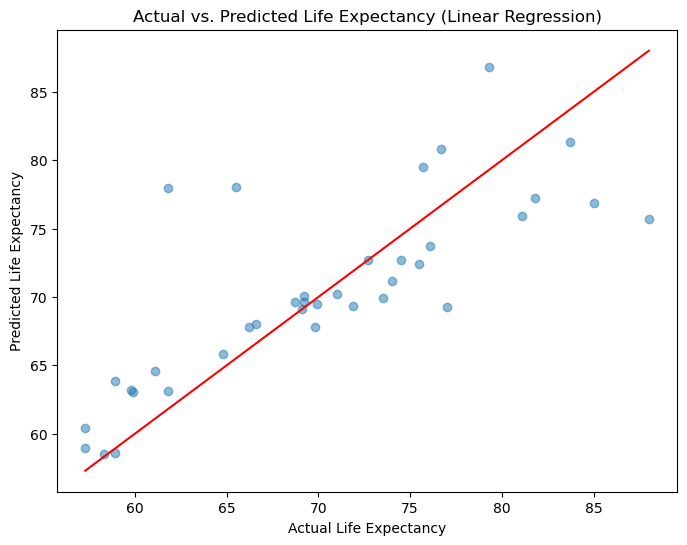

In [84]:
#define the list of features (independent variable) to be used in the model
features = ['GDP', 'Adult Mortality', 'infant deaths']
#intialize the linear regression model
model = LinearRegression()
#define target variable
target = 'Life expectancy'

#call the function to train, evalaute and visualize the model
Multiple_Linear_Regression_Model(life_df, features, target, model, title_suffix='Linear Regression' )


Intercept:  72.01575342465753
Coefficients: 
GDP: 1.7826589190390123
Adult Mortality: -5.427918515146787
infant deaths: -0.6104104837191877
Mean Abosolute error 3.5745887969764
Mean squared error 26.202756651276093
Root Mean squared error 5.118862827940997
R2 0.6186892344589785


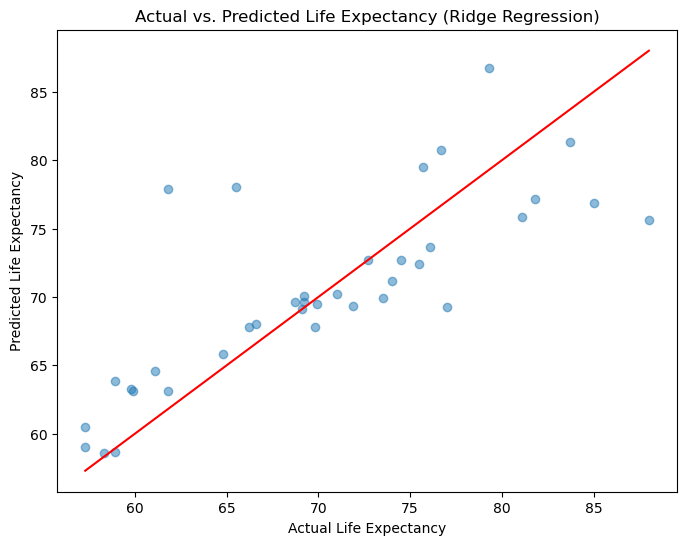

In [85]:

from sklearn.linear_model import Ridge

#define the input feature for the model (independent variables)
features = ['GDP', 'Adult Mortality', 'infant deaths']

#initialize a ridge regression model
model = Ridge()

#define target variable
target = 'Life expectancy'

#call the function to train, evalaute and visualize the model
Multiple_Linear_Regression_Model(life_df, features, target, model, title_suffix='Ridge Regression' )

# Part II: Unsupervised learning models to identify clustering patterns.

## A.Using the k-Means clustering algorithm, identify clusters of countries based on their life expectancy versus GDP

<Axes: xlabel='GDP', ylabel='Life expectancy'>

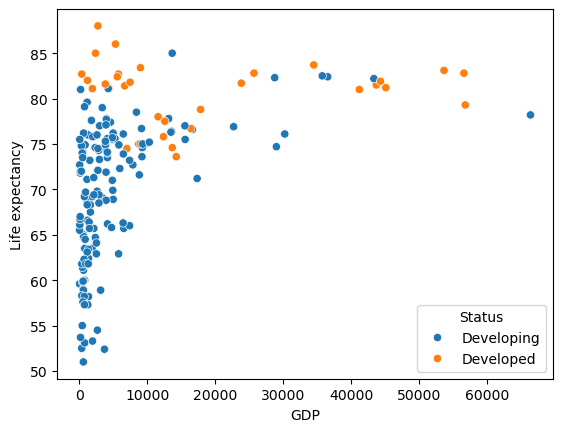

In [86]:
#create a scatter plot of GDP vs Life Expectancy with points colored by Status
sns.scatterplot(data = life_df, x = "GDP", y="Life expectancy", hue='Status')

### From the plot we can see that the developed countries have better life expectancy

The Cluster groupings of countries based on their economic status (GDP) and health outcomes (Life Expectancy)

Cluster with high GDP and high Life expectancy represents developed countries

Cluster with low GDP and low life expectancy includes developing or low-income countries

The middle cluster shows countries with economies in transition or I may say they are improving condition, but they are not there yet

In [88]:
def clustering_algorithm(x1, x2, df, n_clusters=3, max_clusters=11):
    #Select only the two features to be used for clustering
    features_name = [x1, x2]
    x = df[features_name]

    #standard the feature values to have mean-0 and std=1
    scale = StandardScaler()
    scale.fit(x)
    x_scaled = scale.transform(x)

    #Apply Kmean clustering with the specified number of clsuster
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(x_scaled)
  
    #predict cluster labels for each data point
    cluster_labels = kmeans.predict(x_scaled)

    #claculate clustering evaluation metrics
    db_score = davies_bouldin_score(x_scaled, cluster_labels) #lower is better
    s_score = silhouette_score(x_scaled, cluster_labels) #higher is better

    # print the evaluation metrics
    print('DB Score', db_score)
    print('Silhouette Score', s_score)

    #add cluster label to a copy of the selected features for plotting
    clustered_df = x.copy()
    clustered_df['Cluster'] = cluster_labels

    #plot the cluster in 2D space
    plt.figure(figsize=(6, 6))
    sns.scatterplot(data=clustered_df, x=x1, y=x2, hue='Cluster', palette='Set2', s=60)
    #title and label on axes
    plt.title(f"K-Means Clustering: (3 clusters): {x2} vs {x1}")
    plt.xlabel(x1)
    plt.ylabel(x2)
    plt.grid(True)
    plt.legend(title='Cluster')
    #save plot
    plt.savefig(f"Kmeans {x1} vs {x2} {n_clusters} clusters")
    #show plot
    plt.show()

    #generate an Elbow plot to determine optimal number of clusters 
    #create a lsit to store the inertia values for different cluster counts
    inertias = []

    #loop over a range of cluster numbers to evaluate the inertia (1 to 10 clusters)
    for i in range(1, 11):
        kmeans = KMeans(n_clusters=i, random_state=42) #Create KMeans moodel with i clusters
        kmeans.fit(x_scaled) #fit model to scaled data
        inertia = kmeans.inertia_ # sum of Squared distance to cluster centers
        inertias.append(inertia) # store inertia value for plotting
    #plot inertia vs number of clusters
    #The elbow in the plot indicates an optimal number of clusters where the gain in variance slows
    plt.plot(range(1, 11), inertias, marker='o')
    plt.xlabel("Number of Clusters")
    plt.ylabel("Inertia")
    plt.title("Elbow Method")
    plt.grid(True)
    plt.savefig(f"Elbow plot {x1} vs {x2}")
    plt.show()
    
    #Silhouette and DB Score plot
    #create list  to store evaluation scores for each number of clusters
    silhouette_scores = [] #measures how well samples are clustered 
    db_scores = [] #Davies-Bouldin Score
    cluster_range = range(2, max_clusters) #define the range of cluster to test 

    #loop through each cluster count to compute and collect clustering metrics
    for k in cluster_range:
        km = KMeans(n_clusters=k, random_state=42) #initialize KMenas with k clusters
        labels = km.fit_predict(x_scaled) #fit and predict cluster labels
        silhouette_scores.append(silhouette_score(x_scaled, labels))
        db_scores.append(davies_bouldin_score(x_scaled, labels))
    plt.figure(figsize=(12, 5))

    # plot silhouette scores vs Number of clusters
    plt.subplot(1, 2, 1)
    sns.lineplot(x=list(cluster_range), y=silhouette_scores, markers='o')
    plt.title('Silhouette Score vs Number of Clusters')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Silhouette Score')
    plt.grid(True)

    #plot Davies Bouldin Score vs Number of clusters
    plt.subplot(1, 2, 2)
    sns.lineplot(x=list(cluster_range), y=db_scores, markers='o')
    plt.title('Davies-Bouldin Score vs Number of Clusters')
    plt.xlabel('Number of Clusters')
    plt.ylabel('DB Score')
    plt.grid(True)
    plt.tight_layout()

    
    plt.savefig(f"Silhouette_DB_Scores {x1} vs {x2}")
    plt.show()

DB Score 0.5615779766403368
Silhouette Score 0.5460314165429089


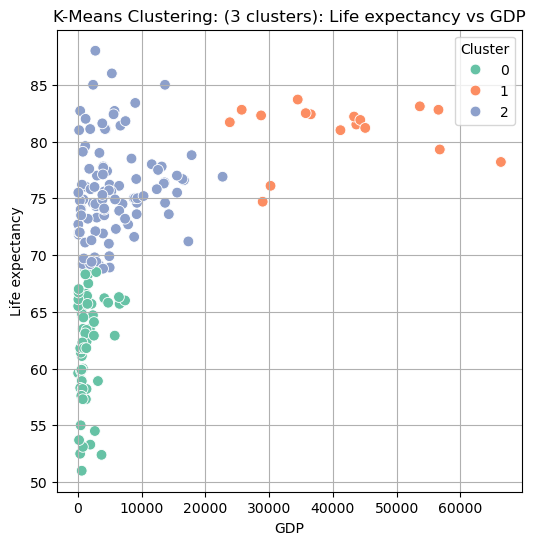

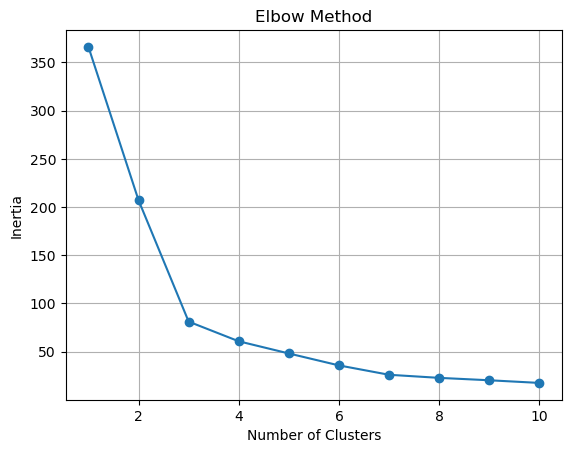

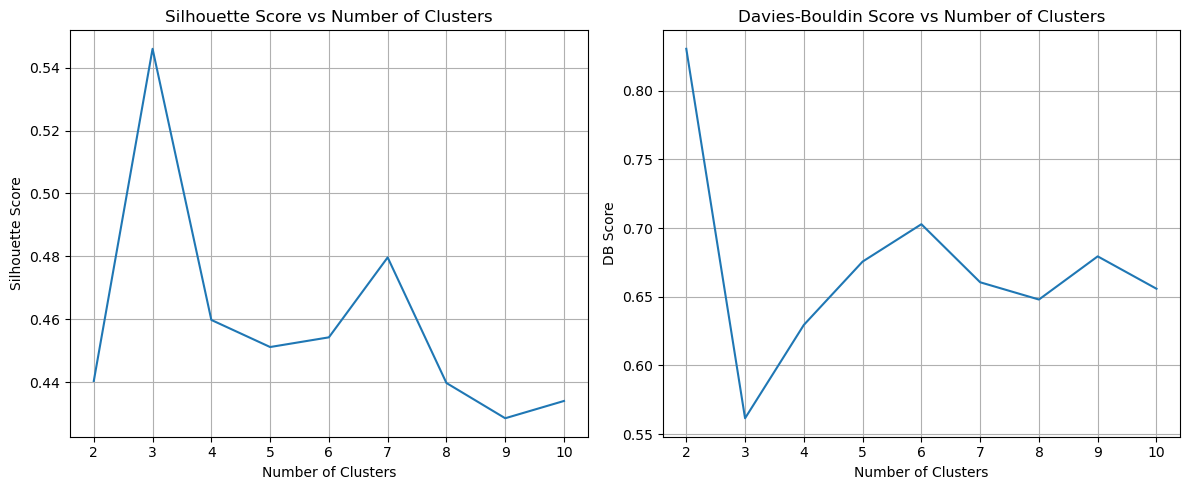

In [89]:
#Apply the KMeans clustering algorithm  tot thr GDP and Life Expectancy features
clustering_algorithm('GDP', 'Life expectancy', life_df)

DB Score 0.7926659315854402
Silhouette Score 0.43534556630050253


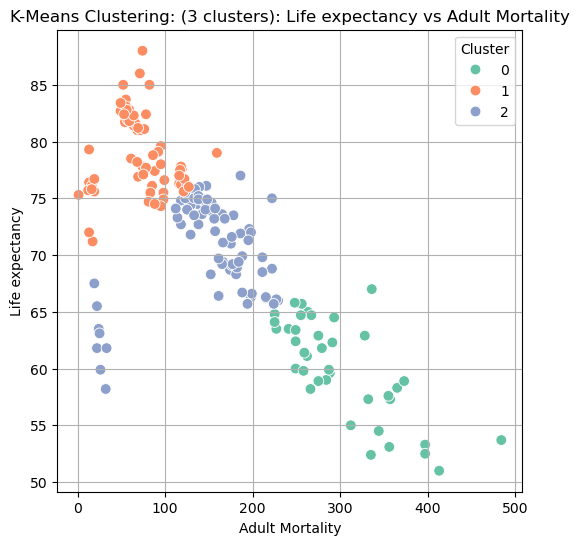

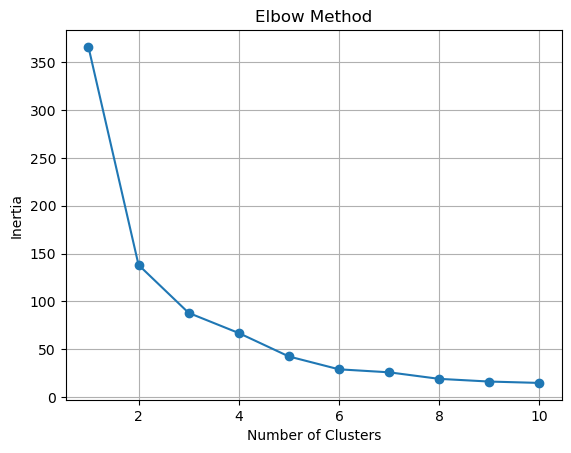

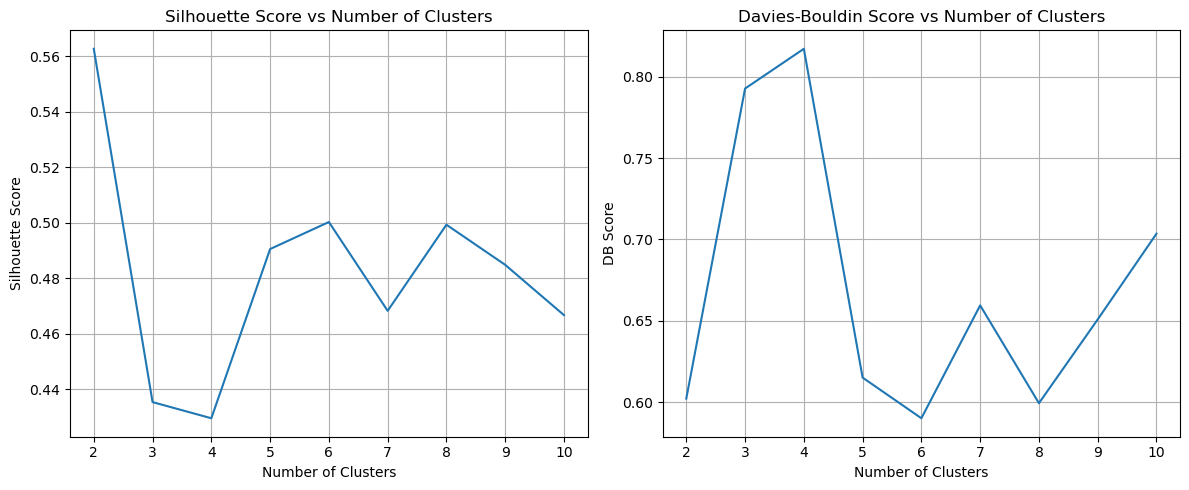

In [90]:
#Apply the KMeans clustering algorithm  tot thr Adult Mortality and Life Expectancy features
clustering_algorithm('Adult Mortality', 'Life expectancy', life_df)

In [91]:
def clusters(x1, x2, model, model_name):
    #select the two features to be used for clustering 
    features = [x1, x2]
    x = life_df[features]

    #standardize the features for better clustering performance
    scale = StandardScaler()
    scale.fit(x)
    x_scaled = scale.transform(x)
    
    #fit the clustering model and predict cluster labels
    
    #compute clustering evaluation metrics
    labels_pred = model.fit_predict(x_scaled)
    
    db_score_agg = davies_bouldin_score(x_scaled, labels_pred) #lower is better
    s_score_agg = silhouette_score(x_scaled, labels_pred) #Higher is better

    #print evaluation scores
    print('DB Score', db_score_agg)
    print('Silhouette Score', s_score_agg)

    #create a copy of the data and add cluster labels for vislization
    x_model = x.copy()
    x_model['Cluster'] = labels_pred

    #plot the figure
    plt.figure(figsize=(6, 6))
    sns.scatterplot(data=x_model, x=x1, y=x2, hue='Cluster', palette='Set2', s=60)
    plt.title(f'{model_name}: (3 clusters) {x2} vs {x1}')
    plt.xlabel(x1)
    plt.ylabel(x2)
    plt.grid(True)
    plt.legend(title='Cluster')

    #Save and Display the plot
    plt.savefig(f"{model_name} {x1} vs {x2}s")
    plt.show()
        
    

DB Score 0.5587872686815339
Silhouette Score 0.4433629465009534


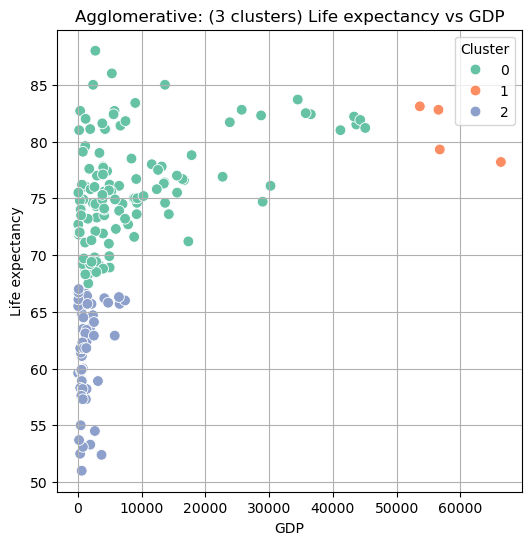

DB Score 0.2791728671765112
Silhouette Score 0.6174900752835009


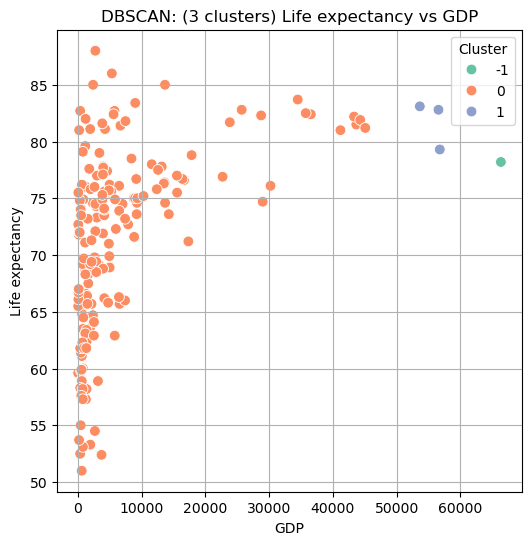

In [92]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

# Apply Agglomerative clustering with 3 clusters and complete linkage on GDP and Life expectancy
model = AgglomerativeClustering(n_clusters=3, linkage='complete')
clusters('GDP', "Life expectancy", model, model_name='Agglomerative')

#Apply DBSCAN Clustering with specified epsilon and minimum samples
model = DBSCAN(eps=0.7, min_samples=3)
clusters('GDP', 'Life expectancy', model, model_name="DBSCAN")